In [24]:
import pickle
import shutil
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from src.config import AIRFOIL_PARAMETRIZATION_MODE, BASELINE_DATA
from src.airfoilTools import Airfoil, parsecParams
from pymoo.indicators.hv import Hypervolume

Load results from the ``` res ```. object. ``` X ``` => Design space variables (i.e Our NACA / PARSEC params), ``` F ``` => Objective space results (i.e Params specified in multi objective optimization, so here, its L/D and Window). ``` xl, xu ``` are lower and upper bounds of the design space variables respectively

In [25]:
# Load data from pickle file and detect parametrization mode
with open("optimization_results.pkl", "rb") as f:
    res = pickle.load(f)

# Here we extract final Pareto front data
X = res.X
F = res.F

xl = res.problem.xl
xu = res.problem.xu

# Baseline normalization factors (adjust if necessary)
base_Cl = BASELINE_DATA['Cl']
base_window = BASELINE_DATA['Window']

# Undo normalization
real_Cl = -F[:, 0] * base_Cl
real_Win = -F[:, 1] * base_window

# Build DataFrame depending on parametrization mode
if AIRFOIL_PARAMETRIZATION_MODE == "PARSEC":
    param_names = ['r_le', 'X_up', 'Z_up', 'Z_XXup',
                   'X_lo', 'Z_lo', 'Z_XXlo',
                   'Z_te', 'delta_Z_te', 'alpha_te', 'beta_te']
    df = pd.DataFrame(X, columns=param_names)

elif AIRFOIL_PARAMETRIZATION_MODE == "NACA":
    param_names = ['digit1', 'digit2', 'digit3_4']
    df = pd.DataFrame(X, columns=param_names)


else:
    raise RuntimeError(f"Unknown parametrization mode: {AIRFOIL_PARAMETRIZATION_MODE}")

# Attach objective columns
df['Cl'] = real_Cl
df['Window'] = real_Win

# Convergence Analysis plots

In [26]:
# Extract optimum of each generation
# Remember again F_hist is raw normalized values
F_hist = [e.opt.get("F")[0] for e in res.history]

# Extract convergence history
cl_hist = [-F_hist[0] * base_Cl for F_hist in F_hist] 
window_hist = [-F_hist[1] * base_window for F_hist in F_hist]
n_nds_his = res.algorithm.callback.data["n_nds"]

fig = go.Figure()

fig.add_trace(go.Scatter(x=np.arange(len(F_hist)), y=cl_hist, mode='lines+markers', 
                         name='Cl', line=dict(color='blue', width=2)))

fig.add_trace(go.Scatter(x=np.arange(len(F_hist)), y=window_hist, mode='lines+markers', 
                         name='Window (deg)', line=dict(color='red', width=2)))

fig.add_trace(go.Scatter(x=np.arange(len(F_hist)), y=n_nds_his, mode='lines+markers', 
                         name='n_nds', line=dict(color='black', width=2)))


fig.update_layout(title='Evolution history of optimum Cl, Window and Number of Non-Dominated Solutions (n_nds)',
                  xaxis_title='Generation',
                  yaxis_title='Objective Values',
                  legend_title='Objectives',
                  template='plotly')

fig.show()

## Running metric plot

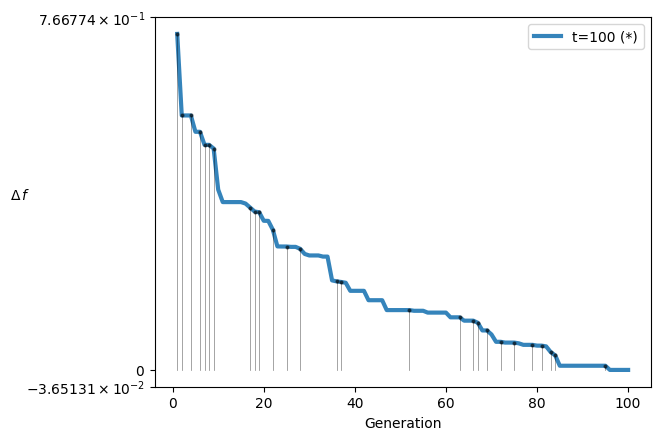

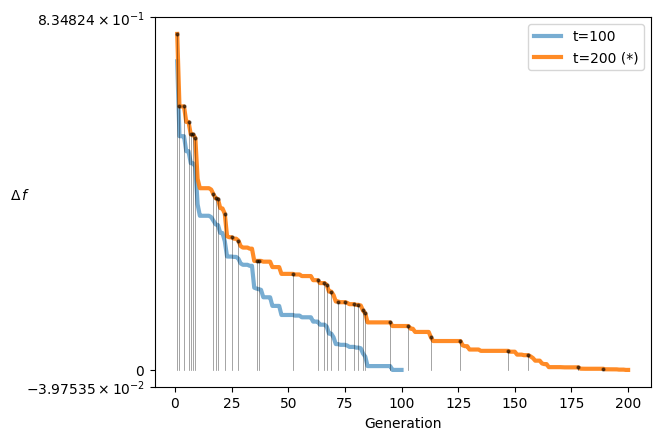

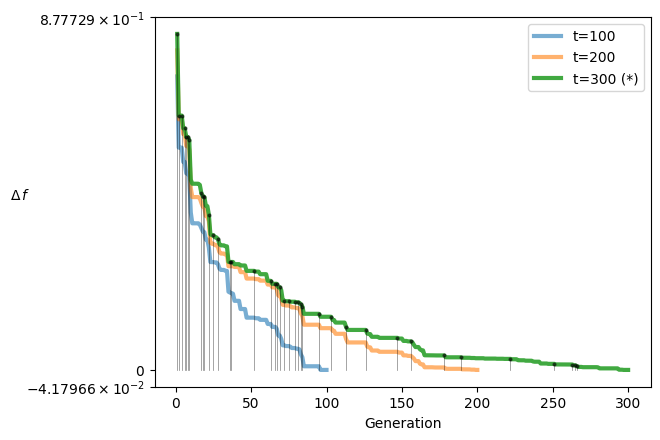

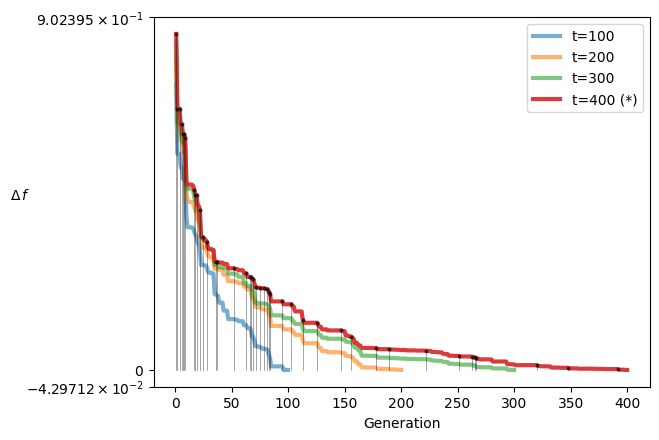

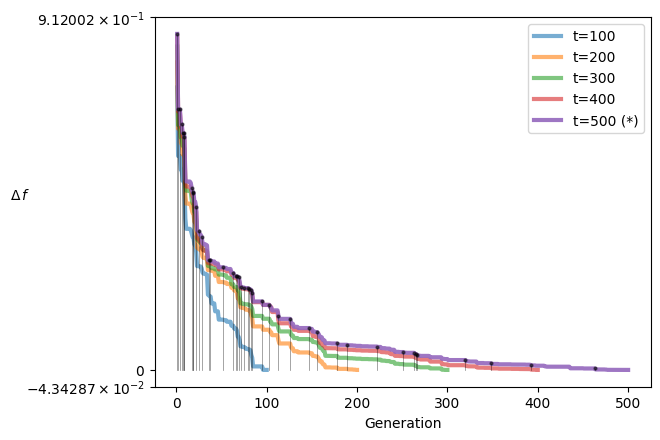

In [27]:
from pymoo.util.running_metric import RunningMetricAnimation

running = RunningMetricAnimation(delta_gen=100,
                        n_plots=5,
                        key_press=False,
                        do_show=True)

for algorithm in res.history[:]: 
    running.update(algorithm)

How to interpret the running metric graph - 

delta f is the "metric", which represents the distance of the current solution from the best solution. Each line represents 100 generations (```delta_gen```). The metric for each line is calculated assuming that the airfoil at the end of 100 generations is the "best". So, for the t=100 line, the airfoil at the 100th gen is the reference, for t=200 its the airfoil at gen=200, so on.

How do you actually assess convergence? A **downard trend** in a `t` line means that the optimizer is able to improve its solution. A **horizontal region** implies a stagnation, where the optimizer is not able to improve the solution. The algorithm is considered to be converged if the changes in the metric are less than 0.25% in the last 30 generations by default. This can be changed in the termination criterion. Overlapping lines also mean that the optimizer is not able to make significant improvements.

*Note* - The running metric graph is defined only for evolutionary algorithms

## Hypervolume plot

In [45]:
metric = Hypervolume(ref_point=np.array([0, 0]), 
                     norm_ref_point=False, 
                     zero_to_one=False)

hv_per_gen = []
generations = []

for i, algo in enumerate(res.history):
    F_gen = algo.opt.get("F")
    hv_val = metric.do(F_gen)
    hv_per_gen.append(hv_val)
    generations.append(i + 1) 

fig = px.line(x=generations, 
              y=hv_per_gen, 
              title='Hypervolume Metric per Generation',
              template='plotly',
              width=1000,
              height=600,
              labels={'x': 'Generation', 'y': 'Hypervolume'})

fig.update_traces(mode='lines+markers', 
                  line=dict(width=2, color='black'),
                  marker=dict(size=6, 
                              color='black', 
                              symbol='diamond-open'))

fig.show()

The Hypervolume is valid for all MOO algorithms and is interpreted similar to the running metric. A flatline indicates a stagnation in the algorithm, and each step indicates an improvement in the objective space

# Design Space visuazlization

Next, lets visualize the Design Space exploration. We'll use a Parallel Coordinates Plot since we have 11 params in the PARSEC parametrization. A simpler representation like the NACA would of course, make the plot less "crowded"

In [29]:

fig = px.parallel_coordinates(
    df, 
    color="Cl",  # Color lines by Cl
    labels={col: col for col in df.columns},
    color_continuous_scale=px.colors.sequential.Viridis,
    title="Overall Design Space exploration",
    template='plotly'
)
fig.show()

In the above graph, we see each *vertical "axes"* representing a *parameter from our airfoil parametrization* method, with the values at the bottom to top being their respective bounds. Note that the last 2 vertical axes are Cl and our airfoil operating window. *Each solution* is represented by a *horizontal line* and colored on the basis of the `color` variable.

Click and drag on a vertical axis to create a filter region to see only those solutions that pass through the specified region. Double click on the axis to remove. You can also move move the vertical axes horizontally by clicking on the variable name and dragging them.

How to analyse - 
1) Clumped lines => An important and sensitive parameter and region. Sparse lines represent the opposite
    - If lines are spread throughout a vertical axes, it means that the output variable is not very sensitve to that design parameter.
2) If lines between vertical axes cross each other, that represents an inverse relationship.

## Pareto Front

In [46]:
fig = px.scatter(df,
                 x='Window',
                 y='Cl',
                 title='Pareto Front of Cl vs Operational Window',
                 template='plotly',
                 width=800,
                 height=600
                 )

fig.update_traces(
    marker=dict(
        size=10,
        color='blue',
        line=dict(
            width=2,
            color='black'
        )
    )

)

fig.add_trace(go.Scatter(x=[df['Window'].max()], 
                         y=[df['Cl'].max()], 
                        name='Ideal point',
                        marker=dict(
                            symbol='star-diamond',          
                            size=18,              
                            color='gold',        
                            line=dict(             
                                color='black',      
                                width=2          
                            )
                        ))
    )

fig.add_trace(go.Scatter(x=[df['Window'].min()], 
                         y=[df['Cl'].min()], 
                        name='Nadir point',
                        marker=dict(
                            symbol='x',          
                            size=18,              
                            color='red',        
                            line=dict(             
                                color='black',      
                                width=2          
                            )
                        ))
    )



fig.update_layout(
    xaxis_title='Operational Window (degrees)'
)


fig.show()

## Plot airfoil of selected point from Pareto Front

In [47]:
desired_foil = 4

In [48]:
# Get params for desired pareto foil, write its dat and polar file
# Construct pareto front data
pareto_front = []
for i in range(len(X)):
    pareto_front.append((real_Cl[i], real_Win[i]))

# Construct input params
input_array = np.array([])
for i in range(0, len(X[desired_foil])):
    input_array = np.append(input_array, X[desired_foil][i])
 
# # Load airfoil
dat_file_name = f"pareto_Front_foil{desired_foil}.dat"
output_path = Path(f"postProcess_data/{dat_file_name}")

if AIRFOIL_PARAMETRIZATION_MODE == "NACA":
    naca_code = input_array.astype(int)
    pareto_airfoil = Airfoil(name=f"pareto_foil_{desired_foil}", pid=999,
                  nacaCode=naca_code)
else:
    params = parsecParams.from_array(input_array)
    pareto_airfoil = Airfoil(name=f"pareto_foil_{desired_foil}", pid=999,
                  params=params)


if AIRFOIL_PARAMETRIZATION_MODE == "PARSEC":
    # Write dat and move polar file to postProcess_data
    pareto_airfoil.xfoil_analysis(mode="PARSEC", Re=250000, alpha_sequence=[0, 20, 1])
    polar_output_path = Path(f"postProcess_data/pareto_Front_foil{desired_foil}_Polar.txt")
    shutil.copy(pareto_airfoil.dat_file, output_path)
    shutil.copy(pareto_airfoil.polar_file, polar_output_path)
    pareto_airfoil.cleanup()
else:
    pareto_airfoil.write_dat_file(out_path=output_path, naca_code=naca_code)
    pareto_airfoil.xfoil_analysis(mode="NACA", Re=250000, alpha_sequence=[0, 20, 1])
    polar_output_path = Path(f"postProcess_data/pareto_Front_foil{desired_foil}_Polar.txt")
    shutil.copy(pareto_airfoil.polar_file, polar_output_path)
    pareto_airfoil.cleanup()

XFOIL timed out for pareto_foil_4


In [50]:
# Load and plot both baseline and pareto airfoil shapes
baseline_dat = np.genfromtxt("postProcess_data/baseline.dat", skip_header=1)
pareto_dat = np.genfromtxt(f"postProcess_data/pareto_Front_foil{desired_foil}.dat", skip_header=1)

baseline_x = baseline_dat[:, 0]
baseline_y = baseline_dat[:, 1]
pareto_x = pareto_dat[:, 0]
pareto_y = pareto_dat[:, 1]

fig = go.Figure()

# Add baseline airfoil
fig.add_trace(go.Scatter(x=baseline_x, y=baseline_y, mode='lines', 
                         name='Baseline', line=dict(color='blue', width=2)))

# Add pareto airfoil
fig.add_trace(go.Scatter(x=pareto_x, y=pareto_y, mode='lines', 
                         name=f'Pareto Foil #{desired_foil}', line=dict(color='red', width=2)))

fig.update_layout(title='Airfoil Comparison: Baseline vs Optimized',
                  xaxis_title='x/c',
                  yaxis_title='y/c',
                  template='plotly',
                  hovermode='closest')

fig.show()

In [34]:
print(X[desired_foil])

[  0.04309726   0.40011723   0.17990944  -0.92         0.64901536
   0.10988165  -1.07032968   0.           0.         -29.94344269
   2.10254107]


In [35]:
# Load polar data for baseline and pareto foil
baseline_polar = np.genfromtxt("postProcess_data/baseline_Polar.txt", skip_header=12)
pareto_polar = np.genfromtxt(f"postProcess_data/pareto_Front_foil{desired_foil}_Polar.txt", skip_header=12)

# If either polar is empty, inform user
if baseline_polar.size == 0:
    raise RuntimeError("Baseline polar file is empty or missing")
if pareto_polar.size == 0:
    raise RuntimeError("Pareto polar file is empty or missing")

baseline_aoa = baseline_polar[:, 0]
baseline_cl = baseline_polar[:, 1]
baseline_cd = baseline_polar[:, 2]
baseline_ld = baseline_cl / baseline_cd

pareto_aoa = pareto_polar[:, 0]
pareto_cl = pareto_polar[:, 1]
pareto_cd = pareto_polar[:, 2]
pareto_ld = pareto_cl / pareto_cd

# Create subplots: 2x2 grid
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Cl vs AoA", "Cd vs AoA", "Cl/Cd vs AoA", "Cl vs Cd")
)

# Cl vs AoA
fig.add_trace(go.Scatter(x=baseline_aoa, y=baseline_cl, mode='lines', name='Baseline', 
                         line=dict(color='blue', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=pareto_aoa, y=pareto_cl, mode='lines', name='Pareto', 
                         line=dict(color='red', width=2)), row=1, col=1)

# Cd vs AoA
fig.add_trace(go.Scatter(x=baseline_aoa, y=baseline_cd, mode='lines', name='Baseline', 
                         line=dict(color='blue', width=2), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=pareto_aoa, y=pareto_cd, mode='lines', name='Pareto', 
                         line=dict(color='red', width=2), showlegend=False), row=1, col=2)

# Cl/Cd vs AoA
fig.add_trace(go.Scatter(x=baseline_aoa, y=baseline_ld, mode='lines', name='Baseline', 
                         line=dict(color='blue', width=2), showlegend=False), row=2, col=1)
fig.add_trace(go.Scatter(x=pareto_aoa, y=pareto_ld, mode='lines', name='Pareto', 
                         line=dict(color='red', width=2), showlegend=False), row=2, col=1)

# Cl vs Cd
fig.add_trace(go.Scatter(x=baseline_cd, y=baseline_cl, mode='lines', name='Baseline', 
                         line=dict(color='blue', width=2), showlegend=False), row=2, col=2)
fig.add_trace(go.Scatter(x=pareto_cd, y=pareto_cl, mode='lines', name='Pareto', 
                         line=dict(color='red', width=2), showlegend=False), row=2, col=2)

# Update axes labels
fig.update_xaxes(title_text="AoA (deg)", row=1, col=1)
fig.update_yaxes(title_text="Cl", row=1, col=1)

fig.update_xaxes(title_text="AoA (deg)", row=1, col=2)
fig.update_yaxes(title_text="Cd", row=1, col=2)

fig.update_xaxes(title_text="AoA (deg)", row=2, col=1)
fig.update_yaxes(title_text="L/D", row=2, col=1)

fig.update_xaxes(title_text="Cd", row=2, col=2)
fig.update_yaxes(title_text="Cl", row=2, col=2)

fig.update_layout(title_text=f"Aerodynamic Polar Comparison: Baseline vs Pareto Foil #{desired_foil}",
                  template='plotly',
                  height=800,
                  width=1200,
                  hovermode='closest')

fig.show()

/tmp/ipykernel_94227/2617556112.py:3: UserWarning:

genfromtxt: Empty input file: "postProcess_data/pareto_Front_foil4_Polar.txt"



RuntimeError: Pareto polar file is empty or missing